# PSI Graph Metrics Analysis

This notebook explores the centrality and community metrics exported to `centrality.csv` for the NC State co-authorship network.

## Workflow

1. Load the metric export.
2. Clean numeric fields and remove duplicates.
3. Visualize distribution patterns across centrality measures.
4. Review top authors and community structure.


## Environment Check

Run this notebook in an environment with the project dependencies installed so plotting and analysis cells execute cleanly.


In [3]:
import sys
print(sys.executable)

/Users/dharani/Desktop/PSI/env/bin/python


In [ ]:
%pip install -r requirements.txt


## Load The Metrics Export

Read the Neo4j-derived centrality table and inspect the first few rows before analysis.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics_df = pd.read_csv('centrality.csv')
metrics_df.head(10)


,Name,degree,weightedDegree,betweenness,closeness,eigenvector,community
0,Stef Elorriaga,2.0,2.0,0.0,0.236907,7.262894e-04,81
1,Katelyn Brandt,1.0,2.0,0.0,0.236495,6.777332e-03,1685
2,Mandeep Kaur Riar,5.0,5.0,0.0,0.271443,4.331718e-03,1287
3,Chenxi Zhang,5.0,5.0,0.0,0.271443,4.331718e-03,1287
4,John Williamson,3.0,3.0,0.0,0.253218,1.875061e-03,40
5,James Burton,3.0,3.0,0.0,0.253218,1.875061e-03,40
6,Shaobo Cai,4.0,4.0,0.0,0.207391,2.853103e-04,735
7,Mahsa Mohiti Asli,4.0,4.0,0.0,0.207391,2.853103e-04,735
8,Alejandro Gutierrez-Li,0.0,0.0,0.0,0.000000,1.903452e-233,8
9,Mary Grace,1.0,1.0,0.0,0.209118,8.382974e-04,25


In [3]:
metrics_df.shape

(1708, 7)

## Deduplicate And Normalize Numeric Columns

Some downstream plots assume a single row per author and numeric metric values, so those checks happen first.


In [6]:
metrics_df = metrics_df.drop_duplicates(subset=['Name'])

In [7]:
metrics_df.shape

(1708, 7)

In [8]:
numeric_cols = ['degree','weightedDegree',
                'betweenness','closeness','eigenvector']

metrics_df[numeric_cols] = metrics_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

## Degree-Based Distributions

These plots summarize collaboration breadth and collaboration intensity across the network.


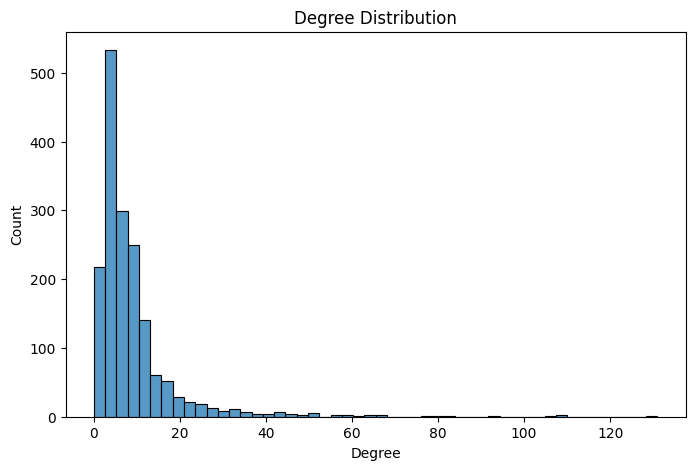

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(metrics_df['degree'], bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

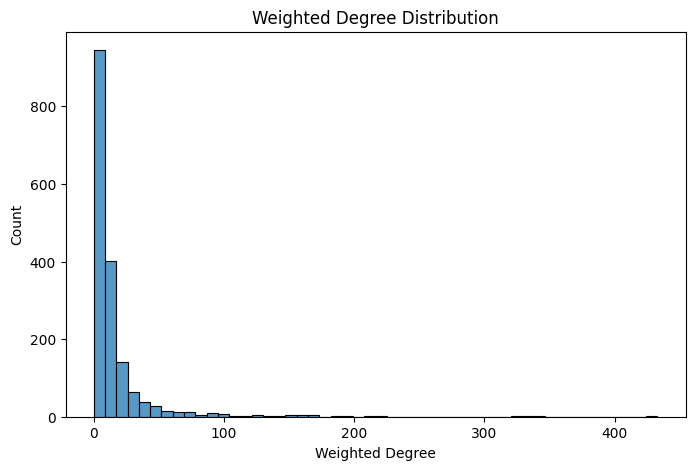

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(metrics_df['weightedDegree'], bins=50)
plt.title("Weighted Degree Distribution")
plt.xlabel("Weighted Degree")
plt.ylabel("Count")
plt.show()

## Centrality Distributions

Normalize the larger-scale metrics where helpful and visualize how influence and reach are distributed.


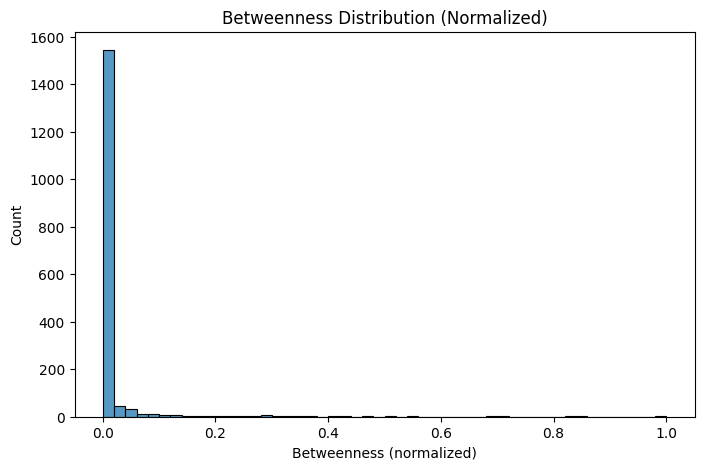

In [22]:
metrics_df['betweenness_norm'] = metrics_df['betweenness'] / metrics_df['betweenness'].max()

plt.figure(figsize=(8,5))
sns.histplot(metrics_df['betweenness_norm'], bins=50)
plt.title("Betweenness Distribution (Normalized)")
plt.xlabel("Betweenness (normalized)")
plt.show()

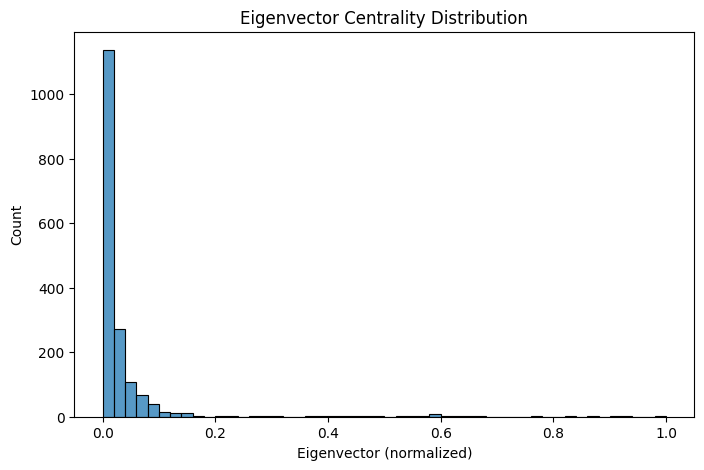

In [12]:
metrics_df['eigenvector_norm'] = metrics_df['eigenvector'] / metrics_df['eigenvector'].max()

plt.figure(figsize=(8,5))
sns.histplot(metrics_df['eigenvector_norm'], bins=50)
plt.title("Eigenvector Centrality Distribution")
plt.xlabel("Eigenvector (normalized)")
plt.show()

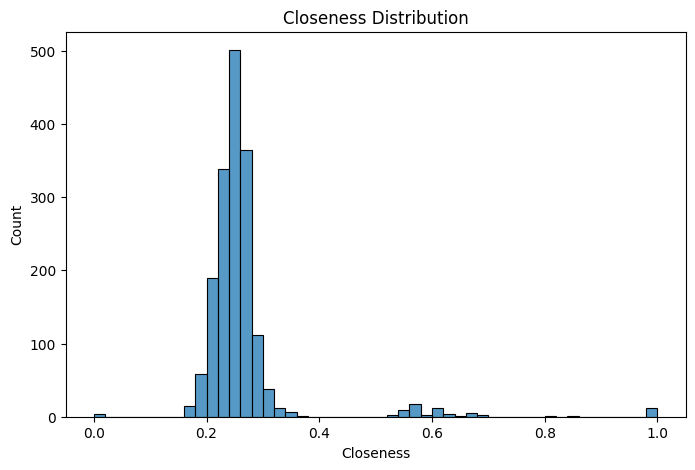

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(metrics_df['closeness'], bins=50)
plt.title("Closeness Distribution")
plt.xlabel("Closeness")
plt.show()

## Top-Ranked Authors

These tables surface the highest-scoring authors for selected metrics.


In [24]:
top_degree = metrics_df.sort_values('degree', ascending=False).head(15)
top_degree[['Name','degree']]

,Name,degree
225,Michael Daniele,131.0
224,Jacob Jones,108.0
298,David Jordan,108.0
258,Alper Bozkurt,106.0
366,Edgar Lobaton,93.0
223,Michael Kudenov,82.0
309,Chris Reberg-Horton,80.0
550,Cranos Williams,76.0
212,Ross Meentemeyer,66.0
236,Qingshan Wei,66.0


In [25]:
top_degree = metrics_df.sort_values('weightedDegree', ascending=False).head(15)
top_degree[['Name','weightedDegree']]

,Name,weightedDegree
298,David Jordan,433.0
225,Michael Daniele,340.0
258,Alper Bozkurt,332.0
224,Jacob Jones,321.0
420,Katherine Jennings,220.0
212,Ross Meentemeyer,215.0
366,Edgar Lobaton,198.0
223,Michael Kudenov,196.0
214,Jack Wang,184.0
272,Kara Peters,172.0


In [26]:
top_eigen = metrics_df.sort_values('eigenvector_norm', ascending=False).head(15)
top_eigen[['Name','eigenvector_norm']]

,Name,eigenvector_norm
550,Cranos Williams,1.000000
214,Jack Wang,0.934005
680,Vincent L Chiang,0.907740
679,Ron Sederoff,0.869958
1636,Chenmin Yang,0.822528
713,Ilona Peszlen,0.772797
1069,Wei Li,0.771747
1192,Hou-Min Chang,0.763885
213,Rodolphe Barrangou,0.661843
801,Hasan Jameel,0.643642


## Metric Relationships

Compare degree and betweenness to see whether broad collaboration also aligns with bridge-like positions in the network.


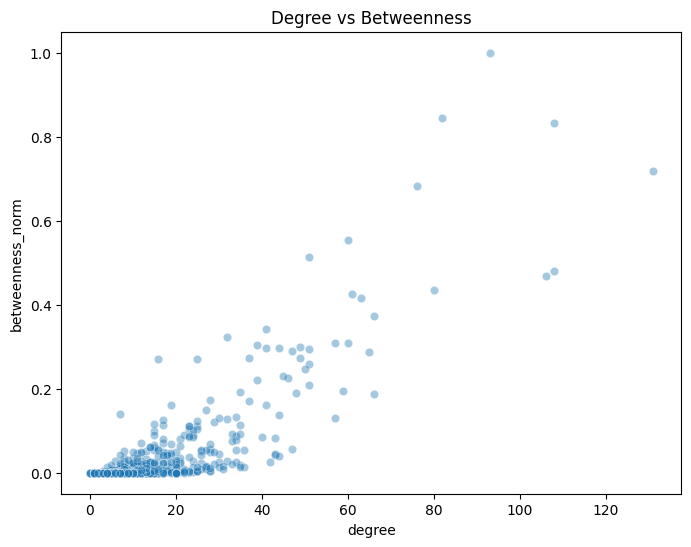

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=metrics_df,
                x='degree',
                y='betweenness_norm',
                alpha=0.4)
plt.title("Degree vs Betweenness")
plt.show()

## Community Structure

Review how many communities appear in the graph and how large the biggest groups are.


In [28]:
metrics_df['community'].nunique()

33

In [29]:
community_sizes = metrics_df['community'].value_counts()
community_sizes.head(10)

community
185     213
1556    173
1405    133
840     107
1221    100
879      99
927      80
897      78
1470     75
1685     74
Name: count, dtype: int64

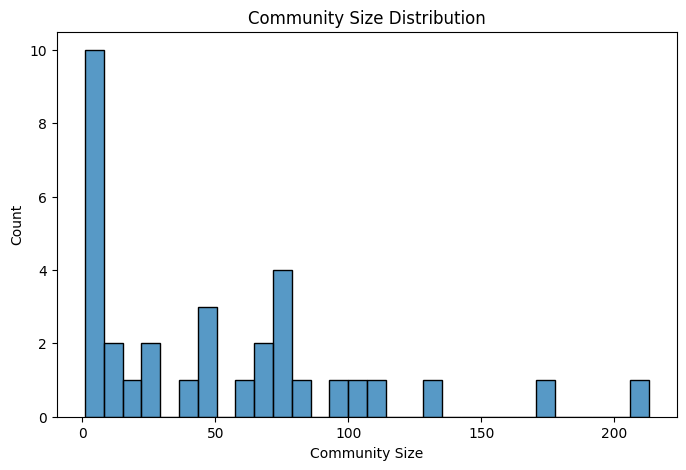

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(community_sizes, bins=30)
plt.title("Community Size Distribution")
plt.xlabel("Community Size")
plt.ylabel("Count")
plt.show()